<a href="https://colab.research.google.com/github/wcaine93/Advanced-Python-Project/blob/main/src/nn-with-normalized-data-training-and-evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# B: Split the data into training and testing data

In [3]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

df = pd.read_csv('clean_data.csv')

### 1. Create the data features (X) and target labels (y).  

In [4]:
X = df.drop('Strength', axis=1)
y = df['Strength']

### 2. Randomly split the data features and labels into a training and test sets by holding 30% of the data for testing.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# D: Normalize the data

Repeat Part C but use a normalized version of the data. Recall that one way to normalize the data is by subtracting the mean from the individual predictors and dividing by the standard deviation.

### Baseline Model + Normalization Layer


According to [Keras docs](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Normalization), the basic `Normalization` layer uses the method given above (`(input - mean)/std`) to normalize data.

In [20]:
normalized_model = tf.keras.models.Sequential([
  tf.keras.Input(shape=(8,)),
  tf.keras.layers.Normalization(axis=None),
  tf.keras.layers.Dense(10, activation='relu'),
  tf.keras.layers.Dense(10, activation='relu'),
  tf.keras.layers.Dense(1)
])

In [21]:
normalized_model.build()

### 2. Plot the model architecture

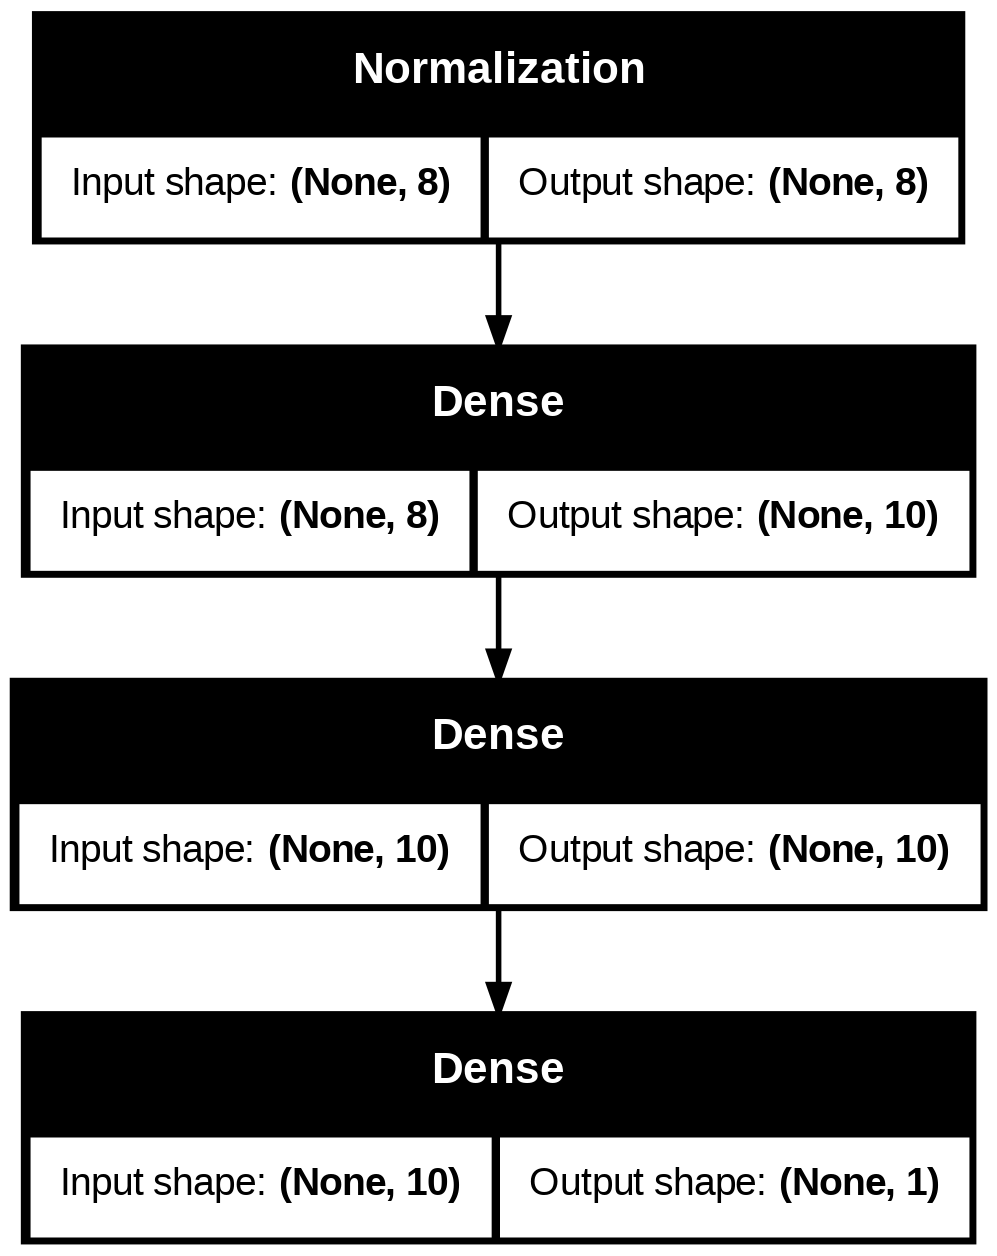

In [12]:
tf.keras.utils.plot_model(normalized_model, to_file='normalized_model.png', show_shapes=True)

### 3. Compile the model using the adam as the optimizer and using the mean squared error as the loss function.

In [22]:
normalized_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

### 4. Train the model on the training data using 100 epochs.

In [23]:
normalized_model.fit(
    X_train, y_train,
    epochs=100
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9444.1777 
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1366.5800
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 698.9403
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 480.1396
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 365.5246
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 295.4334
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 276.7887
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 231.8126
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 222.2787
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 214.2835
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 215.5108
Epoch 12/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 188.4041
Epoch 13/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 189.4881
Epoch 14/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 192.7921
Epoch 15/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 

### 5. Evaluate the model on the test data using model.evaluate

In [24]:
normalized_model.evaluate(X_test, y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 111.0789 


115.0948486328125

Ultimate MSE of `115.09`

### 6. Make predictions on test data using model.predict

In [25]:
normalized_model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([[21.310633 ],
       [14.059832 ],
       [26.151888 ],
       [33.807713 ],
       [39.51549  ],
       [20.837069 ],
       [20.574068 ],
       [36.905804 ],
       [26.650827 ],
       [49.099644 ],
       [35.934307 ],
       [31.535364 ],
       [45.939983 ],
       [46.701252 ],
       [24.71628  ],
       [14.9201145],
       [33.795216 ],
       [37.94588  ],
       [37.16453  ],
       [52.48392  ],
       [34.958706 ],
       [ 5.552477 ],
       [29.685816 ],
       [24.865168 ],
       [ 7.7971363],
       [31.402716 ],
       [44.811672 ],
       [31.98018  ],
       [27.04104  ],
       [48.600475 ],
       [42.09551  ],
       [41.52932  ],
       [51.248543 ],
       [40.526653 ],
       [20.236437 ],
       [61.83339  ],
       [40.003445 ],
       [34.650616 ],
       [39.91669  ],
       [68.071144 ],
       [29.013226 ],
       [28.303537 ],
       [37.06345  ],
       [38.81541  ],
       [49.044308 ],
       [47.99381  ],
       [49.70078  ],
       [25.00